In [1]:
import ipynb
from ipynb.fs.full.utils import *
from ipynb.fs.full.SVM import *
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV 

In [2]:
results=pd.read_csv('pipeline_results_expanded.csv')

In [3]:
averages=results[results['fold']=='avg']
std_devs=results[results['fold']=='std dev']

In [4]:
averages_all=averages[averages['patient']=='all']
std_devs_all=std_devs[std_devs['patient']=='all']

In [70]:
averages_all

,patient,method,fold,test_acc,train_acc,test_precision,train_precision,test_recall,train_recall,test_f1,train_f1,test_roc_auc,train_roc_auc,test_f1_ictal,test_f1_preictal,test_f1_bckg,train_f1_ictal,train_f1_preictal,train_f1_bckg
70,all,svm,avg,0.609643,0.732044,0.613791,0.731994,0.609643,0.732044,0.601038,0.728590,0.786904,0.878589,0.726813,0.511277,0.565023,0.814422,0.676734,0.694614
142,all,rf,avg,0.652864,0.999771,0.657469,0.999773,0.652864,0.999771,0.644849,0.999770,0.825293,0.999995,0.776315,0.542013,0.616220,0.999935,1.000000,1.000000
214,all,logistic,avg,0.588200,0.646931,0.592034,0.643787,0.588200,0.646931,0.578086,0.642086,0.772688,0.818769,0.709995,0.492016,0.532247,0.752711,0.575896,0.604245
286,all,mlp,avg,0.611325,0.717521,0.615505,0.716461,0.611325,0.717521,0.601568,0.713733,0.790245,0.874918,0.722071,0.512938,0.569694,0.804110,0.657640,0.684302


In [71]:
metrics=  np.array([['test_acc', 'train_acc'],
          ['test_precision', 'train_precision'],
          ['test_recall', 'train_recall'],
          ['test_f1', 'train_f1'],
          ['test_roc_auc', 'train_roc_auc'],
          ['test_f1_ictal', 'train_f1_ictal'],
          ['test_f1_preictal', 'train_f1_preictal'],
          ['test_f1_bckg', 'train_f1_bckg']])

In [72]:
titles=['Accuracy', 'Precision', 'Recall', 'F1', 'ROC', 'Ictal F1', 'Preictal F1', 'Background F1']
#titles=['Accuracy', 'Precision', 'Recall', 'F1', 'ROC', 'Ictal F1', 'Background F1']

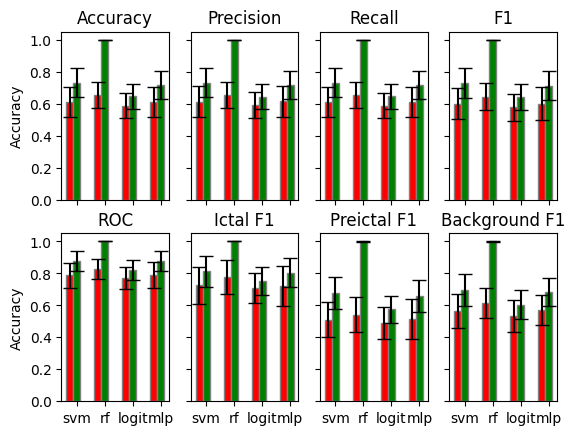

In [73]:
fig, ax= plt.subplots(2,4, sharex=True, sharey=True)
barWidth = 0.25
br1= np.arange(len(averages_all['method']))
br2= [x + barWidth for x in br1]
#plt.bar(averages_all['method'], averages_all['test_acc'])
n=0
for i in np.arange(2):
    for j in np.arange(4):
        ax[i,j].bar(br1, averages_all[metrics[n,0]], color ='r', width = barWidth, 
                edgecolor ='grey', label ='test') 
        ax[i,j].bar(br2, averages_all[metrics[n,1]], color ='g', width = barWidth, 
                edgecolor ='grey', label ='train')
        ax[i,j].set_xticks([r + barWidth for r in range(len(averages_all['test_acc']))], 
                ['svm', 'rf', 'logit', 'mlp'])
        ax[i,j].errorbar(br1, averages_all[metrics[n,0]], yerr=std_devs_all[metrics[n,0]], fmt='none', capsize=5, color='black')
        ax[i,j].errorbar(br2, averages_all[metrics[n,1]], yerr=std_devs_all[metrics[n,1]], fmt='none', capsize=5, color='black')
        #ax[i,j].set_xlabel('Method')
        if j==0:
            ax[i,j].set_ylabel('Accuracy')
        ax[i,j].set_title(titles[n])
        #ax[i,j].legend()
        n=n+1
#plt.ylim(0,1)
plt.show()

In [20]:
averages_rdk=averages[averages['patient']=='aaaaardk']
std_devs_rdk=std_devs[std_devs['patient']=='aaaaardk']

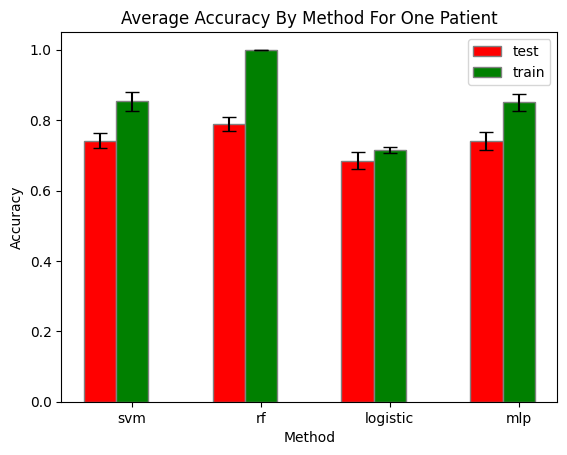

In [23]:
barWidth = 0.25
br1= np.arange(len(averages_all['method']))
br2= [x + barWidth for x in br1]
#plt.bar(averages_all['method'], averages_all['test_acc'])
plt.bar(br1, averages_rdk['test_acc'], color ='r', width = barWidth, 
        edgecolor ='grey', label ='test') 
plt.bar(br2, averages_rdk['train_acc'], color ='g', width = barWidth, 
        edgecolor ='grey', label ='train')
plt.xticks([r + barWidth for r in range(len(averages_rdk['test_acc']))], 
        averages_all['method'])
plt.errorbar(br1, averages_rdk['test_acc'], yerr=std_devs_rdk['test_acc'], fmt='none', capsize=5, color='black')
plt.errorbar(br2, averages_rdk['train_acc'], yerr=std_devs_rdk['train_acc'], fmt='none', capsize=5, color='black')
plt.xlabel('Method')
plt.ylabel('Accuracy')
plt.title('Average Accuracy By Method For One Patient')
plt.legend()
#plt.ylim(0,1)
plt.show()

In [5]:
colors=['blue','orange','green','red','purple','brown','pink','gray','yellow','cyan']
markers=['o','^','x','s']

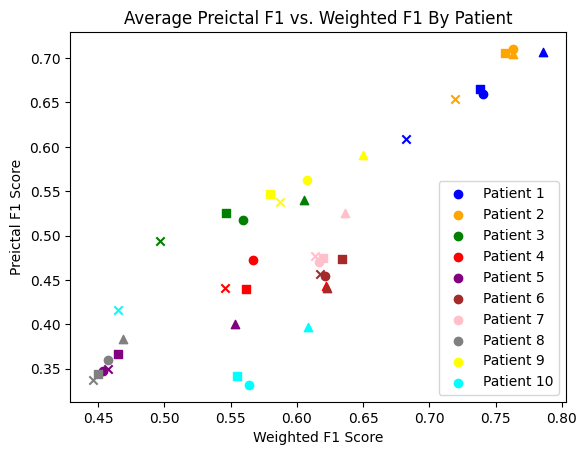

In [7]:
patients=pd.unique(averages['patient'])
for j, patient in enumerate(patients):
    if patient=='all':
        continue
    index=averages.index[averages['patient']==patient]
    for i,n in enumerate(index):
        if i==0:
            plt.scatter(averages.loc[n, 'test_f1'], averages.loc[n, 'test_f1_preictal'], label='Patient '+ str(j+1), c=colors[j], marker=markers[i])
        else:
            plt.scatter(averages.loc[n, 'test_f1'], averages.loc[n, 'test_f1_preictal'], c=colors[j], marker=markers[i])
plt.legend()
plt.xlabel('Weighted F1 Score')
plt.ylabel('Preictal F1 Score')
plt.title('Average Preictal F1 vs. Weighted F1 By Patient')
plt.show()

In [14]:
patient_epochs=pd.read_csv('patient_epochs.csv')

In [9]:
patient_epochs

,patient,epochs
0,aaaaardk,14004
1,aaaaapks,39984
2,aaaaajqo,26676
3,aaaaakfo,10896
4,aaaaates,13065
5,aaaaanme,4140
6,aaaaajns,14673
7,aaaaakkm,15327
8,aaaaalfs,4998
9,aaaaammu,9147


In [10]:
rf_averages=averages[averages['method']=='rf']
drop_index= rf_averages.index[rf_averages['patient']=='all']
rf_averages.drop(drop_index, inplace=True)

/tmp/ipykernel_3021219/1936554858.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rf_averages.drop(drop_index, inplace=True)


In [11]:
rf_averages

,patient,method,fold,test_acc,train_acc,test_precision,train_precision,test_recall,train_recall,test_f1,train_f1,test_roc_auc,train_roc_auc,test_f1_ictal,test_f1_preictal,test_f1_bckg,train_f1_ictal,train_f1_preictal,train_f1_bckg
77,aaaaardk,rf,avg,0.788670,1.0,0.787203,1.0,0.788670,1.0,0.786185,1.0,0.923868,1.0,0.919165,0.706696,0.732694,1.0,1.0,1.0
84,aaaaapks,rf,avg,0.761970,1.0,0.781128,1.0,0.761970,1.0,0.762880,1.0,0.912378,1.0,0.812173,0.704677,0.771791,1.0,1.0,1.0
91,aaaaajqo,rf,avg,0.608203,1.0,0.620484,1.0,0.608203,1.0,0.605316,1.0,0.784611,1.0,0.709241,0.539872,0.566836,1.0,1.0,1.0
98,aaaaakfo,rf,avg,0.630935,1.0,0.630364,1.0,0.630935,1.0,0.621918,1.0,0.822590,1.0,0.826610,0.442735,0.596408,1.0,1.0,1.0
105,aaaaates,rf,avg,0.572631,1.0,0.569389,1.0,0.572631,1.0,0.553692,1.0,0.753457,1.0,0.636590,0.400912,0.623575,1.0,1.0,1.0
112,aaaaanme,rf,avg,0.647177,1.0,0.652150,1.0,0.647177,1.0,0.622755,1.0,0.810310,1.0,0.724965,0.441352,0.701948,1.0,1.0,1.0
119,aaaaajns,rf,avg,0.651293,1.0,0.660208,1.0,0.651293,1.0,0.636688,1.0,0.838310,1.0,0.817058,0.524921,0.568084,1.0,1.0,1.0
126,aaaaakkm,rf,avg,0.486157,1.0,0.501987,1.0,0.486157,1.0,0.468475,1.0,0.702972,1.0,0.569887,0.383686,0.451853,1.0,1.0,1.0
133,aaaaalfs,rf,avg,0.654276,1.0,0.664384,1.0,0.654276,1.0,0.649979,1.0,0.824734,1.0,0.727024,0.590618,0.632294,1.0,1.0,1.0
140,aaaaammu,rf,avg,0.622914,1.0,0.615974,1.0,0.622914,1.0,0.608278,1.0,0.807736,1.0,0.852107,0.397056,0.575673,1.0,1.0,1.0


In [19]:
x=np.asarray(rf_averages['test_acc'])
x

array([0.78866957, 0.76197009, 0.60820329, 0.63093503, 0.57263074,
       0.64717731, 0.65129311, 0.48615654, 0.65427566, 0.62291399])

In [12]:
from scipy.stats import linregress

In [13]:
patients=pd.unique(averages['patient'])
for i in np.arange(len(rf_averages)):
    index=rf_averages.index[rf_averages['patient']==patients[i]]
    plt.scatter(rf_averages.loc[index, 'test_acc'], patient_epochs.loc[i, 'epochs'], label=patient)
a= linregress(x, patient_epochs['epochs'])
m, b= a.slope, a.intercept
plt.plot(x, m*x+b)
plt.legend()
plt.xlabel('Accuracy')
plt.ylabel('Epochs')
plt.title('Number of Epochs vs. Accuracy By Patient')
plt.show()

NameError: name 'patient_epochs' is not defined

In [62]:
print(a.rvalue)
print(a.rvalue**2)
print(a.pvalue)

0.30229145738517027
0.09138012520805021
0.39592272019829566


In [16]:
patient_files=np.array([33,16,16,14,10,10,9,8,7,6])

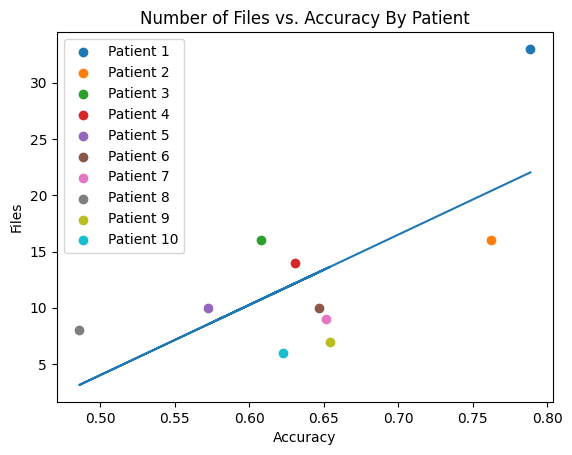

In [20]:
patients=pd.unique(rf_averages['patient'])
for i in np.arange(len(rf_averages)):
    index=rf_averages.index[rf_averages['patient']==patients[i]]
    plt.scatter(rf_averages.loc[index, 'test_acc'], patient_files[i], label='Patient '+ str(i+1))
a= linregress(rf_averages['test_acc'], patient_files)
m, b= a.slope, a.intercept
plt.plot(x, m*x+b)
plt.legend()
plt.xlabel('Accuracy')
plt.ylabel('Files')
plt.title('Number of Files vs. Accuracy By Patient')
plt.show()

In [21]:
print(a.rvalue)
print(a.rvalue**2)
print(a.pvalue)

0.6805044530179224
0.46308631057722177
0.03032943367576401
